## Section 1: Environment Setup & Reproducibility

In [65]:
import os
import copy
import random
import collections
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt

# Scikit-learn Preprocessing, Splitting, and Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, matthews_corrcoef, precision_recall_curve, auc, brier_score_loss, precision_score, recall_score, balanced_accuracy_score
from sklearn.calibration import calibration_curve, CalibrationDisplay

# Imbalanced Learning Frameworks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Machine Learning & Deep Learning Frameworks
from xgboost import XGBClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Explainable AI (XAI) Libraries
import shap
import lime
import lime.lime_tabular

import preprocess

In [66]:
def set_deterministic_seeds(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Force PyTorch algorithms to be deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[*] Global seed locked to {seed}. Deep learning pipeline is now fully reproducible.")

set_deterministic_seeds(42)

[*] Global seed locked to 42. Deep learning pipeline is now fully reproducible.


In [67]:
def evaluate_imbalanced_performance(y_true, y_probs, threshold, model_name="Model"):
    """
    Computes and reports the full imbalanced evaluation metric suite
    stipulated by the thesis supervisor for the attack class (Class 1).
    """
    y_pred = (y_probs >= threshold).astype(int)
    
    # Calculate PR-AUC across continuous probability spectrum
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_probs)
    pr_auc_val = auc(recall_curve, precision_curve)
    
    # Calculate discrete performance indicators for Web Attacks (Class 1)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n{'='*25} {model_name.upper()} UNTOUCHED TEST SET REPORT {'='*25}")
    print(f"Applied Decision Threshold:     {threshold:.2f}")
    print(f"Confusion Matrix (TN, FP, FN, TP):")
    print(cm)
    print(f"{'-'*75}")
    print(f"Attack Precision:               {prec:.4f}")
    print(f"Attack Recall:                  {rec:.4f}")
    print(f"Attack F1-Score:                {f1:.4f}")
    print(f"Precision-Recall AUC (PR-AUC):  {pr_auc_val:.4f}")
    print(f"Matthews Corr Coef (MCC):       {mcc:.4f}")
    print(f"Balanced Accuracy:              {bal_acc:.4f}")
    print(f"{'='*75}\n")
    
    return {
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "pr_auc": pr_auc_val,
        "mcc": mcc,
        "balanced_accuracy": bal_acc,
        "confusion_matrix": cm
    }

## Section 2: Data Loading & Strategic Downsampling
*Loading and preprocessing the (CICIDS-2017 Thursday subset).*

In [68]:
# ==========================================
# UNIFIED DATA SPLIT, SCALING & RESAMPLING
# ==========================================
filepath = "data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
df = preprocess.load_and_clean_dataset(filepath)

# Standardize binary target
df['Label'] = df['Label'].astype(str).str.strip().str.upper()
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X = df.drop(columns=['Label'])
y = df['Label'].values

# Step A: 70% Train, 30% Temp (Stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Step B: 15% Validation, 15% Test (Stratified)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Step C: Leakage-free Scaling (Fit on Train only)
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Step D: Resample strictly on training data
smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
    X_train_scaled, y_train
)

[*] Loading raw dataset from: data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
[*] Dataset Ingestion & Cleaning Audit:
    -> Raw Rows Ingested:          458,968
    -> Empty CSV Padding Purged:   288,602
    -> Valid Network Flows:        170,366
    -> Invalid Flows Dropped (Inf/NaN): 135
    -> Final Usable Flows:         170,231


## Section 3: Baseline IDS Classifier (XGBoost Architecture)
*Training the tree-based model with class imbalance adjustment factors.*

In [69]:
# ==========================================
# UNIFIED XGBOOST TRAINING & CALIBRATION
# ==========================================
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=0.1,
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=15
)

xgb_model.fit(
    X_train_resampled, 
    y_train_resampled,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

# Validation threshold calibration (strictly on validation set)
xgb_val_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]
thresholds_pool = np.arange(0.50, 0.96, 0.05)

best_xgb_threshold = 0.50
best_xgb_f1 = 0.0

for t in thresholds_pool:
    preds = (xgb_val_probs >= t).astype(int)
    f1 = f1_score(y_val, preds, zero_division=0)
    if f1 > best_xgb_f1:
        best_xgb_f1 = f1
        best_xgb_threshold = t

# Predict on untouched Test Set with the frozen threshold
xgb_test_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_test_preds = (xgb_test_probs >= best_xgb_threshold).astype(int)

# Report the complete supervisor metric suite
xgb_test_metrics = evaluate_imbalanced_performance(
    y_true=y_test,
    y_probs=xgb_test_probs,
    threshold=best_xgb_threshold,
    model_name="XGBoost Baseline"
)

c:\Users\Moritz\Documents\Uni\bachlor_thesis\ids-xai-thesis\thesis_env\Lib\site-packages\xgboost\callback.py:385: UserWarning: [11:33:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



========================= XGBOOST BASELINE UNTOUCHED TEST SET REPORT =========================
Applied Decision Threshold:     0.95
Confusion Matrix (TN, FP, FN, TP):
[[25207     1]
 [    4   323]]
---------------------------------------------------------------------------
Attack Precision:               0.9969
Attack Recall:                  0.9878
Attack F1-Score:                0.9923
Precision-Recall AUC (PR-AUC):  0.9982
Matthews Corr Coef (MCC):       0.9922
Balanced Accuracy:              0.9939



## Section 4: Local Attribution Evaluation (XAI Pipeline)
*Isolating True Positive validation flags to extract baseline SHAP and LIME profiles.*

In [70]:
# Locate True Positives using calibrated threshold and test ground truth
true_positive_indices = np.where((y_test == 1) & (xgb_test_preds == 1))[0]

print(f"[*] Found {len(true_positive_indices)} True Positive web attack alerts inside the test split.")

# Extract top instances using the scaled test set
alert_instances_to_explain = X_test_scaled.iloc[true_positive_indices]
alert_ground_truth = y_test[true_positive_indices]

print(f"[+] Isolated {len(alert_instances_to_explain)} test instances for local attribution modeling.")

[*] Found 323 True Positive web attack alerts inside the test split.
[+] Isolated 323 test instances for local attribution modeling.


[*] Initializing SHAP TreeExplainer...

[+] Computing explanations for Alert Case #1...
--- SHAP Top Feature Attributions ---


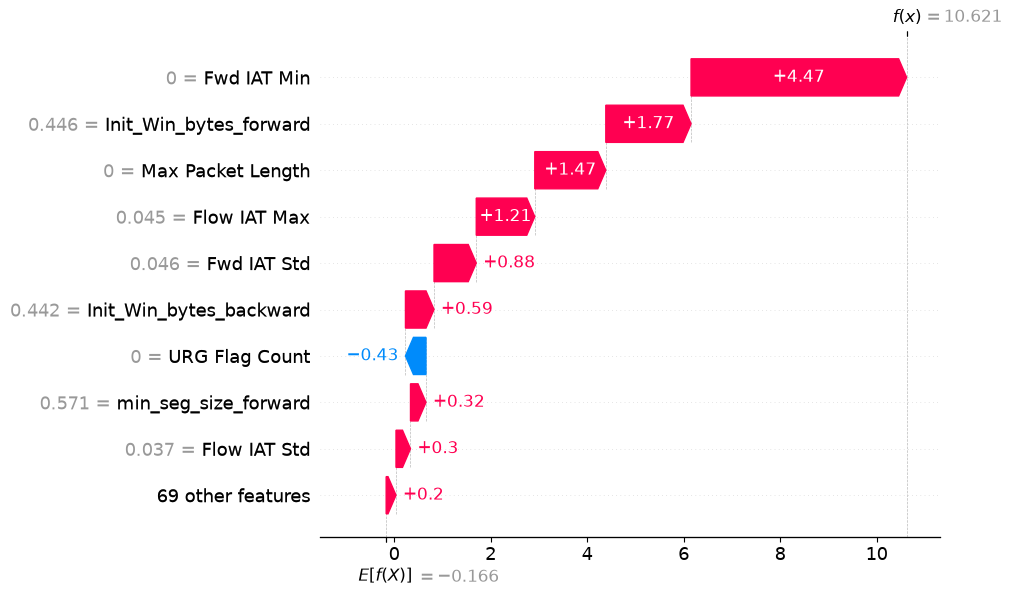

In [71]:
print("[*] Initializing SHAP TreeExplainer...")
explainer_shap = shap.TreeExplainer(xgb_model)

# Calculate Shapley values for the isolated true positive instances (limit to first 10 for compute)
instances_to_eval = alert_instances_to_explain.iloc[:10]
shap_values = explainer_shap(instances_to_eval)

print("\n[+] Computing explanations for Alert Case #1...")
instance_idx = 0
print(f"--- SHAP Top Feature Attributions ---")
shap.plots.waterfall(shap_values[instance_idx], max_display=10)

In [72]:
feature_names = list(X_train_scaled.columns)

# Re-initialize LIME using the scaled training data
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.to_numpy(),
    feature_names=feature_names,
    class_names=['Benign', 'Web Attack'],
    mode='classification',
    random_state=42
)

# Explain the first instance from the scaled subset
instance_idx = 0
print(f"--- LIME Attribution Matrix (Case #{instance_idx}) ---")

exp_lime = explainer_lime.explain_instance(
    data_row=alert_instances_to_explain.iloc[instance_idx].values,
    predict_fn=xgb_model.predict_proba,
    num_features=len(feature_names),
    labels=(1,)
)

for feature, weight in exp_lime.as_list()[:10]:
    print(f"  -> {feature}: {weight:.4f}")

--- LIME Attribution Matrix (Case #0) ---
  -> RST Flag Count <= 0.00: 0.0029
  -> 0.00 < Fwd Header Length.1 <= 0.00: 0.0028
  -> 0.00 < Fwd Header Length <= 0.00: 0.0028
  -> 0.00 < Total Fwd Packets <= 0.00: 0.0025
  -> 0.00 < Subflow Fwd Packets <= 0.00: 0.0023
  -> Init_Win_bytes_forward > 0.13: 0.0022
  -> Flow Duration > 0.01: 0.0015
  -> Fwd IAT Min > 0.00: 0.0014
  -> Flow Bytes/s <= 0.01: 0.0014
  -> Fwd IAT Std > 0.00: 0.0013


In [73]:
def calculate_dataset_metrics(shap_values_matrix, lime_values_matrix, feature_names, k=10):
    """
    Computes average Jaccard Similarity, Top-K Feature Overlap, and 
    Spearman Rank Correlation across all provided true positive alert instances.
    Works seamlessly for both XGBoost and Deep Neural Network explanation runs.
    """
    all_overlaps = []
    all_jaccards = []
    all_spearmans = []
    
    num_instances = shap_values_matrix.shape[0]
    
    for i in range(num_instances):
        shap_vec = shap_values_matrix[i]
        lime_vec = lime_values_matrix[i]
        
        # 1. Extract Top-K feature names based on absolute magnitude
        top_k_shap_idx = np.argsort(np.abs(shap_vec))[-k:][::-1]
        top_k_lime_idx = np.argsort(np.abs(lime_vec))[-k:][::-1]
        
        set_shap = set([feature_names[idx] for idx in top_k_shap_idx])
        set_lime = set([feature_names[idx] for idx in top_k_lime_idx])
        
        # 2. Compute Top-K Intersection Metrics
        intersection = set_shap.intersection(set_lime)
        union = set_shap.union(set_lime)
        
        overlap_count = len(intersection)
        jaccard_idx = overlap_count / len(union) if len(union) > 0 else 0
        
        # 3. Compute Structural Rank Agreement (Spearman's Rho) over all features
        rho, _ = stats.spearmanr(shap_vec, lime_vec)
        if np.isnan(rho):
            rho = 0.0  # Safe fallback for uniform local linear regions
            
        all_overlaps.append(overlap_count)
        all_jaccards.append(jaccard_idx)
        all_spearmans.append(rho)
        
    # Return descriptive metric dictionaries for markdown logging
    return {
        "mean_overlap": np.mean(all_overlaps),
        "mean_jaccard": np.mean(all_jaccards),
        "mean_spearman": np.mean(all_spearmans)
    }

def plot_local_explanations_side_by_side(shap_vector, lime_vector, feature_names, instance_id=0, k=10):
    """
    Generates high-contrast side-by-side horizontal bar plots matching academic 
    formatting standards. Features are ordered by absolute contribution. 
    Bars are colored dynamically: Crimson for positive risk impact, Slate Blue for negative.
    """
    # Isolate absolute top contributors
    shap_top_idx = np.argsort(np.abs(shap_vector))[-k:][::-1]
    lime_top_idx = np.argsort(np.abs(lime_vector))[-k:][::-1]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=False)
    
    # --- Plot Subfigure 1: SHAP Attributions ---
    shap_features = [feature_names[i] for i in shap_top_idx][::-1]
    shap_weights = [shap_vector[i] for i in shap_top_idx][::-1]
    shap_colors = ['#d62728' if w >= 0 else '#1f77b4' for w in shap_weights]
    
    axes[0].barh(shap_features, shap_weights, color=shap_colors, edgecolor='k', alpha=0.85)
    axes[0].set_title(f"SHAP Attribution Profiles (Alert #{instance_id})", fontsize=12, fontweight='bold', pad=12)
    axes[0].axvline(0, color='black', linewidth=1.2, linestyle='--')
    axes[0].grid(axis='x', linestyle=':', alpha=0.6)
    axes[0].set_xlabel("Attribution Magnitude (Additive Shift)", fontsize=10)
    
    # --- Plot Subfigure 2: LIME Attributions ---
    lime_features = [feature_names[i] for i in lime_top_idx][::-1]
    lime_weights = [lime_vector[i] for i in lime_top_idx][::-1]
    lime_colors = ['#d62728' if w >= 0 else '#1f77b4' for w in lime_weights]
    
    axes[1].barh(lime_features, lime_weights, color=lime_colors, edgecolor='k', alpha=0.85)
    axes[1].set_title(f"LIME Local Surrogate Profiles (Alert #{instance_id})", fontsize=12, fontweight='bold', pad=12)
    axes[1].axvline(0, color='black', linewidth=1.2, linestyle='--')
    axes[1].grid(axis='x', linestyle=':', alpha=0.6)
    axes[1].set_xlabel("Surrogate Model Coefficients", fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [74]:
def extract_top_k_shap(shap_instance, feature_names, k=10):
    """
    Extracts the top-k feature names based on absolute SHAP value magnitude.
    """
    # Use absolute values to prioritize overall impact on the alert
    abs_shap = np.abs(shap_instance.values)
    # Sort indices in descending order of importance
    top_indices = np.argsort(abs_shap)[-k:][::-1]
    return [feature_names[i] for i in top_indices]

def extract_top_k_lime(lime_explanation, feature_names, k=10, label=1):
    """
    Extracts top-k feature names directly using integer indices from local_exp,
    bypassing brittle string parsing from as_list().
    """
    # local_exp[label] contains tuples: (feature_index, weight)
    raw_local = lime_explanation.local_exp[label]
    
    # Sort strictly by absolute attribution magnitude
    sorted_local = sorted(raw_local, key=lambda x: abs(x[1]), reverse=True)[:k]
    
    return [feature_names[idx] for idx, _ in sorted_local]

def calculate_xai_consensus(set_a, set_b):
    """
    Computes Raw Top-K Overlap percentage and Jaccard Similarity Index.
    """
    set_a = set(set_a)
    set_b = set(set_b)
    
    intersection = set_a.intersection(set_b)
    union = set_a.union(set_b)
    
    # Raw overlap fraction relative to our target 'k' window
    k_overlap = len(intersection) / len(set_a)
    # Jaccard index handles structural mismatch across the total unique feature pool
    jaccard_index = len(intersection) / len(union) if len(union) > 0 else 0
    
    return len(intersection), k_overlap, jaccard_index

In [75]:
print("[*] Compiling full explanation matrices across XGBoost True Positives...")

# Reset LIME explicitly for determinism using scaled training data
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.to_numpy(),  
    feature_names=feature_names,
    class_names=['Benign', 'Web Attack'],
    mode='classification',
    random_state=42
)

# Bound the sample pool to the first 10 instances (or len(alert_instances_to_explain))
num_xgb_alerts = min(10, len(alert_instances_to_explain))
xgb_eval_instances = alert_instances_to_explain.iloc[:num_xgb_alerts]

# Extract SHAP array for these instances
shap_matrix_xgb = explainer_shap(xgb_eval_instances).values

# Compute aligned LIME matrix targeting Class 1 (Web Attack)
lime_matrix_xgb = np.zeros((num_xgb_alerts, len(feature_names)))
for i in range(num_xgb_alerts):
    raw_row = xgb_eval_instances.iloc[i].values
    exp = explainer_lime.explain_instance(
        data_row=raw_row,
        predict_fn=xgb_model.predict_proba,
        num_features=len(feature_names),
        labels=(1,)
    )
    for f_idx, w in exp.local_exp[1]:
        lime_matrix_xgb[i, f_idx] = w

# Evaluate consensus metrics
xgb_metrics = calculate_dataset_metrics(shap_matrix_xgb, lime_matrix_xgb, feature_names, k=10)

print("\n================== XGBOOST BASELINE XAI CONSENSUS REPORT ==================")
print(f" -> Evaluated True Positive Sample Pool:   {num_xgb_alerts} alert logs")
print(f" -> Average Top-10 Feature Overlap Count:  {xgb_metrics['mean_overlap']:.2f} / 10")
print(f" -> Average Jaccard Similarity Score:      {xgb_metrics['mean_jaccard']:.4f}")
print(f" -> Average Global Spearman Correlation:   {xgb_metrics['mean_spearman']:.4f}")
print("===========================================================================")

[*] Compiling full explanation matrices across XGBoost True Positives...

================== XGBOOST BASELINE XAI CONSENSUS REPORT ==================
 -> Evaluated True Positive Sample Pool:   10 alert logs
 -> Average Top-10 Feature Overlap Count:  2.70 / 10
 -> Average Jaccard Similarity Score:      0.1577
 -> Average Global Spearman Correlation:   0.1649


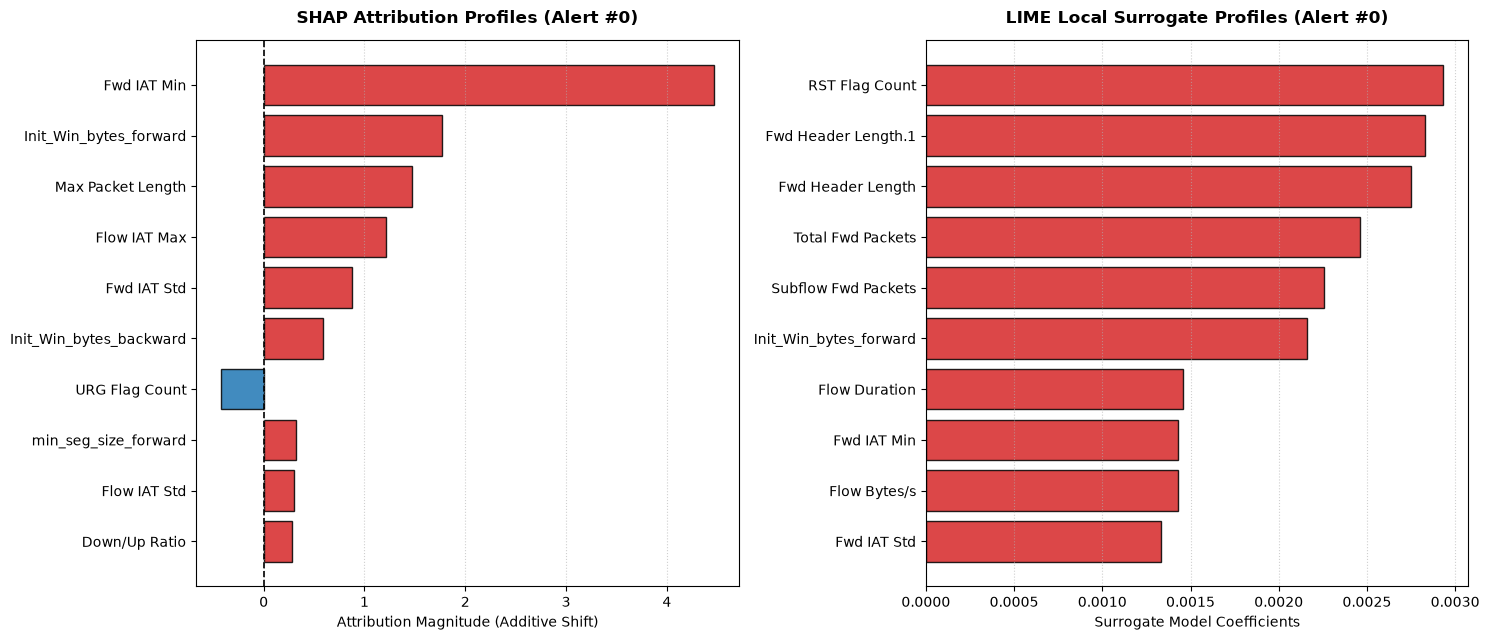

In [76]:
plot_local_explanations_side_by_side(
    shap_matrix_xgb[0], 
    lime_matrix_xgb[0], 
    feature_names, 
    instance_id=0, 
    k=10
)

## Section 5: Deep Neural Network Architecture & Setup
### 5.1 Architecture Formalization
We initialize a regularized multi-layer perceptron (MLP) mapping high-dimensional network attributes to a single predictive dimension. 
* **Input Layer:** Designed dynamically to handle $N=78$ standardized features.
* **Hidden Layer Topology:** Three continuous dense layers configured with $(128 \rightarrow 64)$ hidden units utilizing Rectified Linear Unit ($\text{ReLU}$) activation.
* **Regularization Overlays:** Native Dropout fields set at $30\%$ ($\alpha = 0.3$) to suppress feature-interdependency memorization.
* **Output Node:** Single sigmoid-activated node targeting probability distributions $P(y=1|X)$.

In [77]:
# Set calculation device backend
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class RobustNetworkSecurityDNN(nn.Module):
    def __init__(self, input_dim):
        super(RobustNetworkSecurityDNN, self).__init__()
        
        # Layer 1: Input to Hidden 1
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.30)
        
        # Layer 2: Hidden 1 to Hidden 2
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.30)
        
        # Layer 3: Hidden 2 to Output Layer
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.sigmoid(self.fc3(x))
        return x

input_features_count = X_train_resampled.shape[1]
model_dnn = RobustNetworkSecurityDNN(input_dim=input_features_count).to(device)
print(f"[*] Robust Security DNN architecture initialized on: {device.type.upper()}")

[*] Robust Security DNN architecture initialized on: CPU


In [78]:
# Convert DataFrames/Arrays to PyTorch multi-dimensional tensors
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_resampled.values),
    torch.FloatTensor(y_train_resampled).unsqueeze(1)
)
val_x_tensor = torch.FloatTensor(X_val_scaled.values).to(device)
val_y_tensor = torch.FloatTensor(y_val).unsqueeze(1).to(device)

# Configure data loader iterations
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

# Set optimizer and BCELoss (model outputs probabilities via Sigmoid)
criterion = nn.BCELoss()
optimizer = optim.Adam(model_dnn.parameters(), lr=0.001)

# Early Stopping tracking parameters
patience = 10
best_val_loss = float('inf')
best_model_weights = None
patience_counter = 0
max_epochs = 150

### 5.2 Optimizers, Slicing, and Epoch Execution Loop
The neural network training pipeline optimizes a binary cross-entropy loss function via the Adam configuration. 
To tackle the target scenario distribution bounds without data contamination, class rebalancing is enforced strictly using training-fold boundaries.

In [79]:
print("[*] Initiating DNN optimization loop with Validation Early Stopping...")
for epoch in range(1, max_epochs + 1):
    model_dnn.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model_dnn(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
        
    # Validation Evaluation Phase (Evaluated on X_val, zero test leakage)
    model_dnn.eval()
    with torch.no_grad():
        val_outputs = model_dnn(val_x_tensor)
        val_loss = criterion(val_outputs, val_y_tensor).item()
        
    epoch_train_loss = running_loss / len(train_dataset)
    
    # Early stopping criteria tracking
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model_dnn.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"[*] Early stopping triggered at Epoch {epoch}. Restoring best weights.")
        break

# Roll back parameter matrix states to the optimal validation loss weights
if best_model_weights is not None:
    model_dnn.load_state_dict(best_model_weights)
print(f"[*] Restored optimal model configurations. Best Validation Loss: {best_val_loss:.5f}")

[*] Initiating DNN optimization loop with Validation Early Stopping...
[*] Early stopping triggered at Epoch 21. Restoring best weights.
[*] Restored optimal model configurations. Best Validation Loss: 0.04361


### 5.3 DNN Diagnostic Validation Matrix
Disabling active dropout tracks via `.eval()` states to establish the pipeline baseline. Outputs calculate operational performance metrics including precision, recall, and Macro/Weighted $F_1$-scores across independent validation boundaries.

In [80]:
def get_dnn_probabilities(df_input):
    model_dnn.eval()
    with torch.no_grad():
        tensor_input = torch.FloatTensor(df_input.values).to(device)
        probs = model_dnn(tensor_input).cpu().numpy().flatten()
    return probs

# Collect validation probabilities
dnn_val_probs = get_dnn_probabilities(X_val_scaled)

# Systematically search validation set for F1-optimal threshold
thresholds_pool = np.arange(0.50, 0.96, 0.05)
best_dnn_threshold = 0.50
best_dnn_f1 = 0.0

print("================= DNN VAL THRESHOLD CALIBRATION =================")
for t in thresholds_pool:
    preds = (dnn_val_probs >= t).astype(int)
    f1 = f1_score(y_val, preds, zero_division=0)
    if f1 > best_dnn_f1:
        best_dnn_f1 = f1
        best_dnn_threshold = t
    print(f"Threshold: {t:.2f} | Val F1: {f1:.4f}")

print(f"\n[*] Selected Frozen DNN Threshold: {best_dnn_threshold:.2f} (Val F1: {best_dnn_f1:.4f})")

================= DNN VAL THRESHOLD CALIBRATION =================
Threshold: 0.50 | Val F1: 0.5195
Threshold: 0.55 | Val F1: 0.5304
Threshold: 0.60 | Val F1: 0.5450
Threshold: 0.65 | Val F1: 0.6054
Threshold: 0.70 | Val F1: 0.6681
Threshold: 0.75 | Val F1: 0.7687
Threshold: 0.80 | Val F1: 0.8626
Threshold: 0.85 | Val F1: 0.8555
Threshold: 0.90 | Val F1: 0.8547
Threshold: 0.95 | Val F1: 0.8571

[*] Selected Frozen DNN Threshold: 0.80 (Val F1: 0.8626)


## Section 6: Local Attribution Extraction for Deep Architectures
### 6.1 Isolating True Positive Validation Signatures
We programmatically isolate network sequence indices where both the true ground truth label equals class 1 (Malicious Flow) and the neural model output crosses our operational activation threshold. This creates our base cohort for explanation extraction.

In [81]:
# Predict strictly on untouched test set using the frozen calibrated threshold
dnn_test_probs = get_dnn_probabilities(X_test_scaled)
dnn_test_preds = (dnn_test_probs >= best_dnn_threshold).astype(int)

# Report the complete supervisor metric suite
dnn_test_metrics = evaluate_imbalanced_performance(
    y_true=y_test,
    y_probs=dnn_test_probs,
    threshold=best_dnn_threshold,
    model_name="Robust DNN Baseline"
)


========================= ROBUST DNN BASELINE UNTOUCHED TEST SET REPORT =========================
Applied Decision Threshold:     0.80
Confusion Matrix (TN, FP, FN, TP):
[[25126    82]
 [   19   308]]
---------------------------------------------------------------------------
Attack Precision:               0.7897
Attack Recall:                  0.9419
Attack F1-Score:                0.8591
Precision-Recall AUC (PR-AUC):  0.9106
Matthews Corr Coef (MCC):       0.8606
Balanced Accuracy:              0.9693



In [82]:
# Standardized probability wrappers for the explainers
def dnn_predict_proba_wrapper(x_numpy):
    df_temp = pd.DataFrame(x_numpy, columns=X_train_scaled.columns)
    probs_class_1 = get_dnn_probabilities(df_temp)
    probs_class_0 = 1.0 - probs_class_1
    return np.column_stack((probs_class_0, probs_class_1))

# Initialize LIME using scaled reference space
feature_names = list(X_train_scaled.columns)
lime_explainer_dnn = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=feature_names,
    class_names=['Benign', 'Web Attack'],
    mode='classification',
    random_state=42
)

# Pick first true positive using our calibrated threshold
true_positives = np.where((y_test == 1) & (dnn_test_preds == 1))[0]
sample_idx = true_positives[0]

print(f"[*] Extracting baseline LIME attributions for Test Index: {sample_idx}")
lime_exp = lime_explainer_dnn.explain_instance(
    data_row=X_test_scaled.iloc[sample_idx].values,
    predict_fn=dnn_predict_proba_wrapper,
    num_features=10,
    labels=(1,)
)

for feature_name, importance in lime_exp.as_list():
    print(f"    -> {feature_name}: {importance:.6f}")

[*] Extracting baseline LIME attributions for Test Index: 4
    -> 0.00 < Fwd Header Length <= 0.00: 0.002763
    -> 0.00 < Fwd Header Length.1 <= 0.00: 0.002643
    -> 0.00 < Total Fwd Packets <= 0.00: 0.002627
    -> 0.00 < Subflow Fwd Packets <= 0.00: 0.002401
    -> Init_Win_bytes_forward > 0.13: 0.002113
    -> RST Flag Count <= 0.00: 0.001463
    -> Fwd IAT Min > 0.00: 0.001460
    -> Flow Duration > 0.01: 0.001406
    -> Fwd IAT Std > 0.00: 0.001292
    -> Flow Bytes/s <= 0.01: 0.001273


In [83]:
print("[*] Initializing SHAP background reference space...")

# Sample background from scaled train data
shap_background_baseline = shap.sample(X_train_scaled, 100, random_state=42)

shap_explainer_dnn = shap.KernelExplainer(
    model=dnn_predict_proba_wrapper, 
    data=shap_background_baseline,
    random_state=42
)

print(f"[*] Computing Shapley values for target sample index {sample_idx}...")
shap_raw_dnn = shap_explainer_dnn.shap_values(X_test_scaled.iloc[sample_idx].values.reshape(1, -1))

if isinstance(shap_raw_dnn, list):
    shap_values_dnn = shap_raw_dnn[1].flatten()
elif isinstance(shap_raw_dnn, np.ndarray) and len(shap_raw_dnn.shape) == 3:
    shap_values_dnn = shap_raw_dnn[0, :, 1]
else:
    shap_values_dnn = shap_raw_dnn.flatten()

sorted_indices = np.argsort(np.abs(shap_values_dnn))[::-1]
print("\n================== SHAP TOP ATTRIBUTIONS ==================")
for idx in sorted_indices[:10]:
    print(f"    -> {feature_names[idx]}: {shap_values_dnn[idx]:.6f}")

[*] Initializing SHAP background reference space...
[*] Computing Shapley values for target sample index 4...


  0%|          | 0/1 [00:00<?, ?it/s]


================== SHAP TOP ATTRIBUTIONS ==================
    -> Init_Win_bytes_backward: 0.169554
    -> Init_Win_bytes_forward: 0.146464
    -> PSH Flag Count: 0.145865
    -> Protocol: 0.095160
    -> min_seg_size_forward: 0.095106
    -> Bwd Packet Length Min: 0.076480
    -> ACK Flag Count: 0.068737
    -> Down/Up Ratio: 0.061018
    -> Min Packet Length: 0.055275
    -> Max Packet Length: 0.047108


In [84]:
# Isolate True Positives matching test labels and calibrated threshold
dnn_true_positive_indices = np.where((y_test == 1) & (dnn_test_preds == 1))[0]
dnn_alert_instances = X_test_scaled.iloc[dnn_true_positive_indices]

print(f"[*] Isolated {len(dnn_alert_instances)} True Positive alerts for DNN attribution evaluation.")

num_dnn_alerts = min(10, len(dnn_alert_instances))  # Keep calculation bounded
shap_matrix_dnn = np.zeros((num_dnn_alerts, len(feature_names)))
lime_matrix_dnn = np.zeros((num_dnn_alerts, len(feature_names)))

for i in range(num_dnn_alerts):
    instance_raw = dnn_alert_instances.iloc[i].values
    
    np.random.seed(42)
    s_vals = shap_explainer_dnn.shap_values(instance_raw.reshape(1, -1))
    if isinstance(s_vals, list):
        shap_matrix_dnn[i] = s_vals[1].flatten()
    elif isinstance(s_vals, np.ndarray) and len(s_vals.shape) == 3:
        shap_matrix_dnn[i] = s_vals[0, :, 1]
    else:
        shap_matrix_dnn[i] = s_vals.flatten()
        
    exp = lime_explainer_dnn.explain_instance(
        data_row=instance_raw,
        predict_fn=dnn_predict_proba_wrapper,
        num_features=len(feature_names),
        labels=(1,)
    )
    for f_idx, w in exp.local_exp[1]:
        lime_matrix_dnn[i, f_idx] = w

dnn_metrics = calculate_dataset_metrics(shap_matrix_dnn, lime_matrix_dnn, feature_names, k=10)

print("\n==================== DNN BASELINE XAI CONSENSUS REPORT ====================")
print(f" -> Evaluated True Positive Sample Pool:   {num_dnn_alerts} alert logs")
print(f" -> Average Top-10 Feature Overlap Count:  {dnn_metrics['mean_overlap']:.2f} / 10")
print(f" -> Average Jaccard Similarity Score:      {dnn_metrics['mean_jaccard']:.4f}")
print(f" -> Average Global Spearman Correlation:   {dnn_metrics['mean_spearman']:.4f}")
print("===========================================================================")

[*] Isolated 308 True Positive alerts for DNN attribution evaluation.


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


==================== DNN BASELINE XAI CONSENSUS REPORT ====================
 -> Evaluated True Positive Sample Pool:   10 alert logs
 -> Average Top-10 Feature Overlap Count:  1.90 / 10
 -> Average Jaccard Similarity Score:      0.1066
 -> Average Global Spearman Correlation:   0.1797


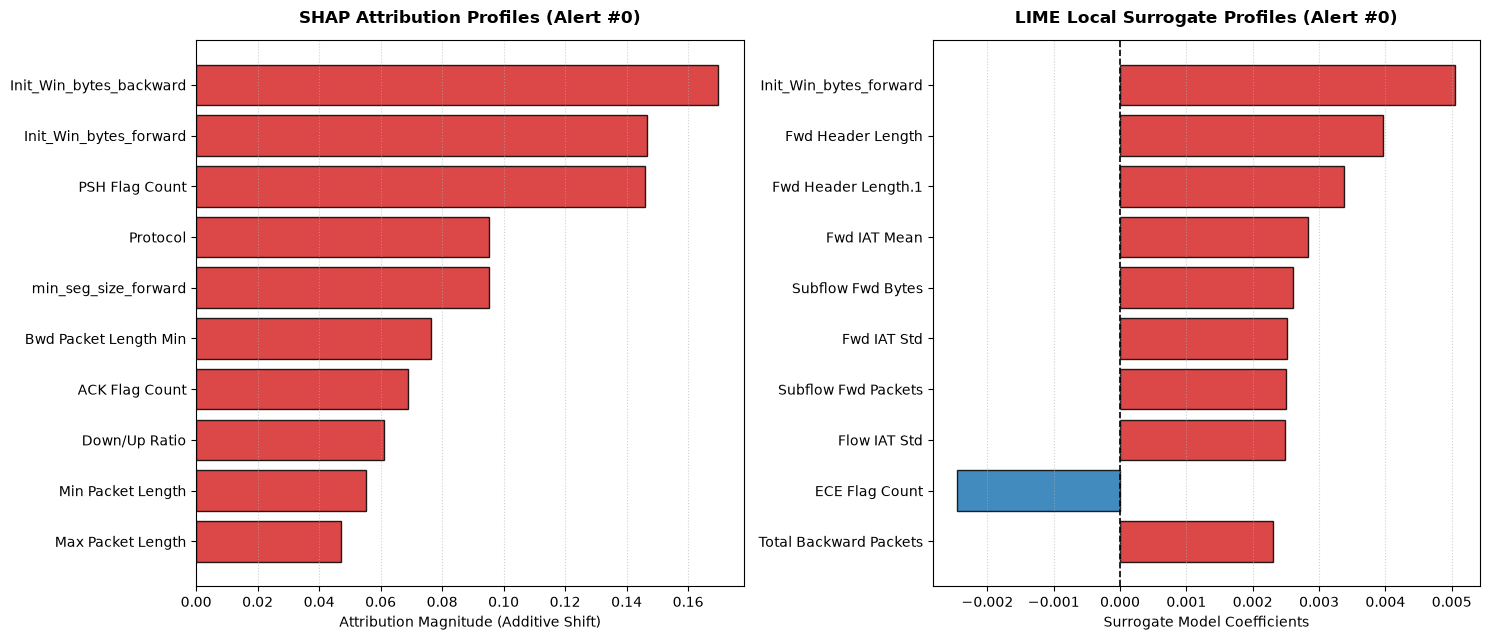

In [85]:
# 4. Render side-by-side local verification plot for your first DNN target case
plot_local_explanations_side_by_side(
    shap_matrix_dnn[0], 
    lime_matrix_dnn[0], 
    feature_names, 
    instance_id=0, 
    k=10
)

In [86]:
num_feats = len(feature_names)

# 1. Define high-sample Stable LIME Explainer (N=5000) using scaled reference data
stable_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=feature_names,
    class_names=['Benign', 'Web Attack'],
    mode='classification',
    kernel_width=0.75,
    random_state=42
)

print("[*] Extracting Stable LIME for unperturbed instance...")
lime_exp_stable_orig = stable_lime_explainer.explain_instance(
    data_row=X_test_scaled.iloc[sample_idx].values,
    predict_fn=dnn_predict_proba_wrapper,
    num_features=num_feats,
    labels=(1,)
)

# 2. Define dense-background Robust SHAP (K=50 Summary)
robust_background = shap.kmeans(X_train_scaled.values, 50)
robust_shap_explainer = shap.KernelExplainer(
    model=dnn_predict_proba_wrapper, 
    data=robust_background, 
    random_state=42
)

print("[*] Extracting Robust SHAP for unperturbed instance...")
shap_raw_robust = robust_shap_explainer.shap_values(X_test_scaled.iloc[sample_idx].values.reshape(1, -1))

if isinstance(shap_raw_robust, list):
    shap_values_robust_orig = shap_raw_robust[1].flatten()
elif isinstance(shap_raw_robust, np.ndarray) and len(shap_raw_robust.shape) == 3:
    shap_values_robust_orig = shap_raw_robust[0, :, 1]
else:
    shap_values_robust_orig = shap_raw_robust.flatten()

# Dynamic helper function to extract array weights from LIME objects
def extract_lime_vector(lime_exp_obj, target_cols, label=1):
    """
    Constructs a dense attribution vector aligned with target_cols
    using integer indices from local_exp[label].
    """
    vec = np.zeros(len(target_cols))
    raw_local_exp = lime_exp_obj.local_exp[label]
    
    # Map index directly to dense position
    for f_idx, weight in raw_local_exp:
        vec[f_idx] = weight
        
    return vec

# Build full feature arrays for unperturbed instance
v_lime_std_orig = extract_lime_vector(lime_exp, feature_names)
v_lime_stable_orig = extract_lime_vector(lime_exp_stable_orig, feature_names)
v_shap_std_orig = shap_values_dnn
v_shap_robust_orig = shap_values_robust_orig

# Compute cross-explainer baseline agreement
rho_std_vs_std, _ = stats.spearmanr(v_shap_std_orig, v_lime_std_orig)
rho_robust_vs_stable, _ = stats.spearmanr(v_shap_robust_orig, v_lime_stable_orig)

print("\n" + "="*15 + " UNPERTURBED XAI CONSENSUS MATRIX " + "="*15)
print(f"--> Standard SHAP vs Standard LIME Agreement (Rho): {rho_std_vs_std:.4f}")
print(f"--> Robust SHAP vs Stable LIME Agreement (Rho):   {rho_robust_vs_stable:.4f}")

[*] Extracting Stable LIME for unperturbed instance...
[*] Extracting Robust SHAP for unperturbed instance...


  0%|          | 0/1 [00:00<?, ?it/s]


=============== UNPERTURBED XAI CONSENSUS MATRIX ===============
--> Standard SHAP vs Standard LIME Agreement (Rho): -0.0203
--> Robust SHAP vs Stable LIME Agreement (Rho):   0.0952


In [90]:
# --- Sanity Check for LIME Vector & Top-K Extraction ---
sample_row = X_test_scaled.iloc[0].values
exp_test = explainer_lime.explain_instance(
    data_row=sample_row,
    predict_fn=xgb_model.predict_proba,
    num_features=len(feature_names),
    labels=(1,)
)

# Test dense vector
dense_v = extract_lime_vector(exp_test, feature_names)
# Test top-k extraction
top_10 = extract_top_k_lime(exp_test, feature_names, k=10)

print(f"[*] Dense vector shape: {dense_v.shape} (Expected: ({len(feature_names)},))")
print(f"[*] Non-zero features count: {np.count_nonzero(dense_v)}")
print(f"[*] Top-10 features extracted directly via index:")
for rank, feat in enumerate(top_10, 1):
    print(f"    {rank}. {feat} (Weight: {dense_v[feature_names.index(feat)]:.4e})")

assert dense_v.shape == (len(feature_names),), "Dense vector shape mismatch!"
assert len(top_10) == 10, "Top-K list length mismatch!"
assert np.count_nonzero(dense_v) > 0, "Dense vector has all zeros!"
print("[+] LIME attribution-vector extraction passed successfully!")

[*] Dense vector shape: (78,) (Expected: (78,))
[*] Non-zero features count: 68
[*] Top-10 features extracted directly via index:
    1. Flow IAT Std (Weight: 1.0393e-04)
    2. Active Max (Weight: -8.9822e-05)
    3. Flow IAT Mean (Weight: 8.8015e-05)
    4. Flow Packets/s (Weight: 8.6681e-05)
    5. Bwd IAT Min (Weight: 8.6265e-05)
    6. Idle Max (Weight: -8.3302e-05)
    7. ACK Flag Count (Weight: -8.1442e-05)
    8. Fwd IAT Min (Weight: 8.1112e-05)
    9. ECE Flag Count (Weight: 6.7331e-05)
    10. Bwd Header Length (Weight: 6.4214e-05)
[+] LIME attribution-vector extraction passed successfully!


In [88]:
# 1. Apply Continuous Metric Perturbation (Noise Simulation)
original_instance = X_test_scaled.iloc[sample_idx].values.reshape(1, -1)
np.random.seed(42)
noise = np.random.normal(0, 0.05, original_instance.shape)
# Data is MinMax scaled, so clipping strictly to [0.0, 1.0] preserves valid input range
perturbed_instance = np.clip(original_instance + noise, 0.0, 1.0)

# 2. Extract explanations for perturbed point
print("[*] Computing perturbed instances across all explainers...")
lime_exp_std_pert = lime_explainer_dnn.explain_instance(
    data_row=perturbed_instance.ravel(), 
    predict_fn=dnn_predict_proba_wrapper, 
    num_features=num_feats,
    labels=(1,)
)
lime_exp_stable_pert = stable_lime_explainer.explain_instance(
    data_row=perturbed_instance.ravel(), 
    predict_fn=dnn_predict_proba_wrapper, 
    num_features=num_feats,
    labels=(1,)
)

# Extract and shape SHAP outputs cleanly
shap_raw_std_pert = shap_explainer_dnn.shap_values(perturbed_instance)
if isinstance(shap_raw_std_pert, list):
    shap_values_std_pert = shap_raw_std_pert[1].flatten()
elif isinstance(shap_raw_std_pert, np.ndarray) and len(shap_raw_std_pert.shape) == 3:
    shap_values_std_pert = shap_raw_std_pert[0, :, 1]
else:
    shap_values_std_pert = shap_raw_std_pert.flatten()

shap_raw_rob_pert = robust_shap_explainer.shap_values(perturbed_instance)
if isinstance(shap_raw_rob_pert, list):
    shap_values_robust_pert = shap_raw_rob_pert[1].flatten()
elif isinstance(shap_raw_rob_pert, np.ndarray) and len(shap_raw_rob_pert.shape) == 3:
    shap_values_robust_pert = shap_raw_rob_pert[0, :, 1]
else:
    shap_values_robust_pert = shap_raw_rob_pert.flatten()

# Map vector representations
v_lime_std_pert = extract_lime_vector(lime_exp_std_pert, feature_names)
v_lime_stable_pert = extract_lime_vector(lime_exp_stable_pert, feature_names)

# 3. Calculate Rank Stability Degradation (Self-Similarity: Orig vs Perturbed)
stability_shap_std, _ = stats.spearmanr(v_shap_std_orig, shap_values_std_pert)
stability_shap_robust, _ = stats.spearmanr(v_shap_robust_orig, shap_values_robust_pert)
stability_lime_std, _ = stats.spearmanr(v_lime_std_orig, v_lime_std_pert)
stability_lime_stable, _ = stats.spearmanr(v_lime_stable_orig, v_lime_stable_pert)

print("\n" + "="*15 + " EXPLAINER ROBUSTNESS METRICS (ORIG vs PERTURBED) " + "="*15)
print(f"--> Standard SHAP Stability Rank Preservation: {stability_shap_std:.4f}")
print(f"--> Robust SHAP Stability Rank Preservation:   {stability_shap_robust:.4f}")
print(f"--> Standard LIME Stability Rank Preservation: {stability_lime_std:.4f}")
print(f"--> Stable LIME Stability Rank Preservation:   {stability_lime_stable:.4f}")

[*] Computing perturbed instances across all explainers...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


=============== EXPLAINER ROBUSTNESS METRICS (ORIG vs PERTURBED) ===============
--> Standard SHAP Stability Rank Preservation: -0.0781
--> Robust SHAP Stability Rank Preservation:   0.1461
--> Standard LIME Stability Rank Preservation: 0.0546
--> Stable LIME Stability Rank Preservation:   -0.1281


In [89]:
print("================== COMMENCING TARGETED EXPLANATION ATTACK (I-ATTACK) ==================")

# 1. Isolate the target True Positive Web Attack instance from scaled test data
x_attack = X_test_scaled.iloc[sample_idx].copy()

# Find a representative Benign sample to serve as the adversarial target profile
benign_indices = np.where(y_test == 0)[0]
x_benign_target = X_test_scaled.iloc[benign_indices[0]]

# 2. Execute targeted perturbation on a highly influential feature
# Dynamically locate the window bytes column name if formatted with spaces/underscores
target_candidate_cols = [c for c in feature_names if "init_win_bytes_forward" in c.lower().replace(" ", "_")]
mutable_target_feature = target_candidate_cols[0] if target_candidate_cols else feature_names[0]

x_adversarial = x_attack.copy()
# Shift the scaled value 80% closer to the benign baseline distribution
x_adversarial[mutable_target_feature] = x_attack[mutable_target_feature] + 0.8 * (
    x_benign_target[mutable_target_feature] - x_attack[mutable_target_feature]
)

# 3. Verify Prediction Integrity (Ensuring the attack classification holds above threshold)
df_orig = pd.DataFrame([x_attack.values], columns=feature_names)
df_adv = pd.DataFrame([x_adversarial.values], columns=feature_names)

prob_original = get_dnn_probabilities(df_orig)[0]
prob_adversarial = get_dnn_probabilities(df_adv)[0]

print(f"[*] Target Feature Altered: {mutable_target_feature}")
print(f"    -> Original Scaled Value:          {x_attack[mutable_target_feature]:.4f}")
print(f"    -> Adversarial Shifted Value:      {x_adversarial[mutable_target_feature]:.4f}")
print(f"    -> Calibrated Decision Threshold:  {best_dnn_threshold:.2f}")
print(f"    -> Post-Attack Model Prediction:   {'Web Attack' if prob_adversarial >= best_dnn_threshold else 'Benign'}")
print(f"    -> Verification Probabilities:      Original={prob_original:.4f} -> Adversarial={prob_adversarial:.4f}")

# 4. Extract Shifted LIME explanation to check ranking changes
print("\n[*] Re-evaluating LIME explanations on the targeted adversarial sample...")
lime_exp_adversarial = lime_explainer_dnn.explain_instance(
    data_row=x_adversarial.values,
    predict_fn=dnn_predict_proba_wrapper,
    num_features=5,
    labels=(1,)
)

print("\n================== POST-ATTACK LOCAL ATTRIBUTIONS ==================")
for feature_name_str, importance in lime_exp_adversarial.as_list():
    print(f"    -> {feature_name_str}: {importance:.6f}")

================== COMMENCING TARGETED EXPLANATION ATTACK (I-ATTACK) ==================
[*] Target Feature Altered: Init_Win_bytes_forward
    -> Original Scaled Value:          0.4456
    -> Adversarial Shifted Value:      0.0891
    -> Calibrated Decision Threshold:  0.80
    -> Post-Attack Model Prediction:   Benign
    -> Verification Probabilities:      Original=0.9965 -> Adversarial=0.0000

[*] Re-evaluating LIME explanations on the targeted adversarial sample...

================== POST-ATTACK LOCAL ATTRIBUTIONS ==================
    -> Active Max <= 0.00: -0.001162
    -> Active Min <= 0.00: -0.001147
    -> Bwd Packet Length Std <= 0.00: -0.000896
    -> Fwd Packet Length Max <= 0.00: 0.000890
    -> Subflow Bwd Bytes <= 0.00: 0.000768
